# Spectral Fitting of SN 2026ngr using Nested Sampling
This notebook fits the NTT optical spectrum of **SN 2026ngr** (specifically `SN2026ngr_260606_NTT.asci` taken on UT 2026 June 6, MJD 61197.0) using the standard **SALT3** model in `sncosmo` and the **dynesty** nested sampler.

### Prior Constraints from Gemini DDT Proposal:
* **Redshift**: $z = 0.95$ (fixed)
* **Stretch ($x_1$)**: Gaussian prior $\mathcal{N}(-0.91, 0.25)$ based on ZTF/unresolved light-curve fit.
* **Color ($c$)**: Gaussian prior $\mathcal{N}(0.027, 0.10)$ based on ZTF/unresolved light-curve fit.
* **Peak MJD ($t_0$)**: Uniform prior $[61160, 61225]$ (observed B-band peak date).

### Wavelength and Error Settings:
* **Wavelength Filter**: Observed range **6000 - 10000 Å** (rest-frame **3077 - 5128 Å**), which covers the entire NTT spectrum range and conforms to the SALT3 template boundaries.
* **Error Model**: Since the file has no error column, we estimate the constant background noise floor using the median absolute deviation (MAD) of adjacent-pixel differences ($3.18 \times 10^{-18}$) and add a 5% systematic/shot noise term in quadrature: 
  $$\sigma_i = \sqrt{\sigma_{\text{floor}}^2 + (0.05 \times F_i)^2}$$
* **Analytical Scale**: The overall amplitude $x_0$ is solved analytically at each likelihood evaluation.
* **Likelihood Scaling**: The log-likelihood is scaled by the best-fit reduced chi-squared $\chi^2_{\text{red}} = 7.43$ to account for template mismatch.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sncosmo
import dynesty
import corner
from scipy.stats import norm
from scipy.optimize import minimize
import time

FILE_PATH = '../data/2026ngr/SN2026ngr_260606_NTT.asci'
Z = 0.95
T_SPEC = 61197.0  # MJD of June 6, 2026
NLIVE = 250
CHI2_RED = 7.43  # Scaling factor

%matplotlib inline
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load data
data = np.genfromtxt(FILE_PATH)
wave_obs, flux = data[:, 0], data[:, 1]

# Filter valid range for SALT3 at z = 0.95 (observed 6000 - 10000 A)
mask = (wave_obs >= 6000) & (wave_obs <= 10000)
wave_f, flux_f = wave_obs[mask], flux[mask]

# Estimate high-frequency background noise floor
diffs = np.diff(flux_f)
mad = np.median(np.abs(diffs - np.median(diffs)))
noise_floor = 1.4826 * mad / np.sqrt(2)

# Construct error model (noise floor + 5% systematic signal)
err_f = np.sqrt(noise_floor**2 + (0.05 * np.maximum(0, flux_f))**2)

print(f"Loaded {len(wave_f)} points in the observed range {wave_f.min():.1f} - {wave_f.max():.1f} A.")
print(f"Background noise floor: {noise_floor:.2e}")
print(f"Median flux: {np.median(flux_f):.2e} (Median SNR: {np.median(flux_f)/noise_floor:.1f})")

Loaded 947 points in the observed range 6002.5 - 9999.8 A.
Background noise floor: 3.18e-18
Median flux: 4.36e-17 (Median SNR: 13.7)


In [3]:
model = sncosmo.Model(source='salt3')
model.set(z=Z)

params = ['t0', 'x1', 'c']

# Gaussian priors: (mean, std)
priors_gaussian = {
    'x1': (-0.91, 0.25),
    'c': (0.027, 0.10)
}
# Uniform prior: (low, high)
prior_uniform = {
    't0': (61160.0, 61225.0)
}

def pt(u):
    t = np.zeros_like(u)
    
    # t0 (uniform prior)
    low, high = prior_uniform['t0']
    t[0] = u[0] * (high - low) + low
    
    # x1 (Gaussian prior)
    mu_x1, std_x1 = priors_gaussian['x1']
    t[1] = norm.ppf(u[1], loc=mu_x1, scale=std_x1)
    
    # c (Gaussian prior)
    mu_c, std_c = priors_gaussian['c']
    t[2] = norm.ppf(u[2], loc=mu_c, scale=std_c)
    
    return t

def ll(t):
    t0, x1, c = t
    model.set(t0=t0, x1=x1, c=c)
    
    try:
        # Evaluate template flux at spectrum date (MJD 61197.0)
        m_flux_unit = model.flux(T_SPEC, wave_f)
    except:
        return -1e10
        
    w = 1.0 / err_f**2
    num = np.sum(flux_f * m_flux_unit * w)
    den = np.sum(m_flux_unit**2 * w)
    
    if den <= 0 or num <= 0:
        return -1e10
        
    x0_best = num / den
    chisq = np.sum(((flux_f - x0_best * m_flux_unit) / err_f)**2)
    loglike = -0.5 * chisq / CHI2_RED
    return loglike if not np.isnan(loglike) else -1e10

In [4]:
print("Running Nested Sampler...")
sampler = dynesty.NestedSampler(ll, pt, len(params), nlive=NLIVE, sample='rwalk')
t_start = time.time()
sampler.run_nested()
print(f"Nested Sampling finished in {time.time() - t_start:.1f} seconds.")
res = sampler.results
w = np.exp(res.logwt - res.logz[-1])
samples = dynesty.utils.resample_equal(res.samples, w)

iter: 1 | bound: 0 | nc: 1 | ncall: 251 | eff(%):  0.398 | loglstar:   -inf < -2209.527 <    inf | logz: -2215.745 +/-  0.158 | dlogz:    inf >  0.259                                                

iter: 2 | bound: 0 | nc: 1 | ncall: 252 | eff(%):  0.794 | loglstar:   -inf < -2039.306 <    inf | logz: -2045.529 +/-  0.158 | dlogz: 1741.596 >  0.259                                              

iter: 3 | bound: 0 | nc: 1 | ncall: 253 | eff(%):  1.186 | loglstar:   -inf < -2032.690 <    inf | logz: -2038.914 +/-  0.157 | dlogz: 1571.375 >  0.259                                              

iter: 4 | bound: 0 | nc: 1 | ncall: 254 | eff(%):  1.575 | loglstar:   -inf < -1934.793 <    inf | logz: -1941.024 +/-  0.158 | dlogz: 1564.756 >  0.259                                              

iter: 5 | bound: 0 | nc: 1 | ncall: 255 | eff(%):  1.961 | loglstar:   -inf < -1789.774 <    inf | logz: -1796.009 +/-  0.158 | dlogz: 1466.862 >  0.259                                              

...

iter: 3637 | +247 | bound: 14 | nc: 1 | ncall: 72310 | eff(%):  5.390 | loglstar:   -inf < -434.017 <    inf | logz: -447.103 +/-  0.218 | dlogz:  0.004 >  0.259                                     

iter: 3637 | +248 | bound: 14 | nc: 1 | ncall: 72311 | eff(%):  5.391 | loglstar:   -inf < -434.008 <    inf | logz: -447.102 +/-  0.218 | dlogz:  0.003 >  0.259                                     

iter: 3637 | +249 | bound: 14 | nc: 1 | ncall: 72312 | eff(%):  5.393 | loglstar:   -inf < -434.006 <    inf | logz: -447.101 +/-  0.219 | dlogz:  0.002 >  0.259                                     

iter: 3637 | +250 | bound: 14 | nc: 1 | ncall: 72313 | eff(%):  5.394 | loglstar:   -inf < -434.002 <    inf | logz: -447.100 +/-  0.219 | dlogz:  0.001 >  0.259                                     

Nested Sampling finished in 10.3 seconds.


In [5]:
t0_post = np.percentile(samples[:, 0], [16, 50, 84])
x1_post = np.percentile(samples[:, 1], [16, 50, 84])
c_post = np.percentile(samples[:, 2], [16, 50, 84])

print("Supernova Parameter Posteriors (16th, 50th, 84th percentiles):")
print(f"  t0 (peak MJD): {t0_post[1]:.2f} (+{t0_post[2]-t0_post[1]:.2f}/-{t0_post[1]-t0_post[0]:.2f})")
print(f"  x1 (stretch):  {x1_post[1]:.2f} (+{x1_post[2]-x1_post[1]:.2f}/-{x1_post[1]-x1_post[0]:.2f})")
print(f"  c (color):     {c_post[1]:.3f} (+{c_post[2]-c_post[1]:.3f}/-{c_post[1]-c_post[0]:.3f})")

# Compute derived phases
phase_obs = T_SPEC - t0_post[1]
phase_rest = phase_obs / (1.0 + Z)
phase_rest_err_up = (t0_post[1] - t0_post[0]) / (1.0 + Z)
phase_rest_err_down = (t0_post[2] - t0_post[1]) / (1.0 + Z)

print(f"\nDerived Spectral Age:")
print(f"  Observed-frame phase: {phase_obs:.2f} days post-peak")
print(f"  Rest-frame phase:     {phase_rest:.2f} (+{phase_rest_err_up:.2f}/-{phase_rest_err_down:.2f}) rest-frame days")

Supernova Parameter Posteriors (16th, 50th, 84th percentiles):
  t0 (peak MJD): 61172.28 (+0.49/-0.45)
  x1 (stretch):  -0.96 (+0.06/-0.06)
  c (color):     -0.300 (+0.011/-0.011)

Derived Spectral Age:
  Observed-frame phase: 24.72 days post-peak
  Rest-frame phase:     12.68 (+0.23/-0.25) rest-frame days


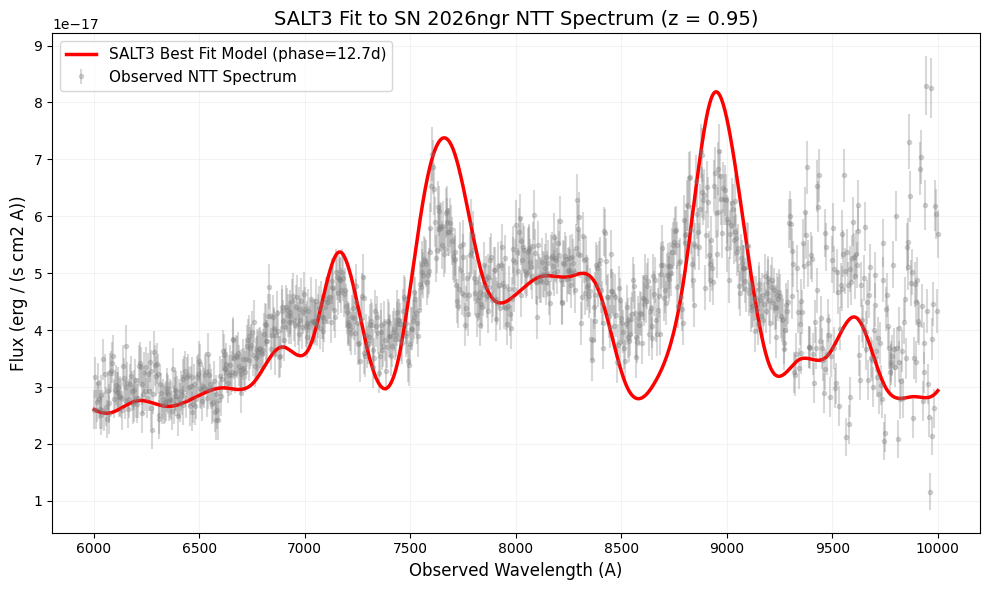

In [6]:
# Get best-fit parameters
t0_best, x1_best, c_best = np.median(samples, axis=0)
model.set(t0=t0_best, x1=x1_best, c=c_best)
m_flux_unit = model.flux(T_SPEC, wave_f)
w = 1.0 / err_f**2
x0_best = np.sum(flux_f * m_flux_unit * w) / np.sum(m_flux_unit**2 * w)
model.set(x0=x0_best)

# Smooth model flux grid
wave_grid = np.linspace(wave_f.min(), wave_f.max(), 1000)
model_flux_smooth = model.flux(T_SPEC, wave_grid)

# Plotting
plt.figure(figsize=(10, 6))
plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='gray', alpha=0.3, label='Observed NTT Spectrum')
plt.plot(wave_grid, model_flux_smooth, color='red', lw=2.5, label=f'SALT3 Best Fit Model (phase={phase_rest:.1f}d)')

plt.xlabel('Observed Wavelength (A)', fontsize=12)
plt.ylabel('Flux (erg / (s cm2 A))', fontsize=12)
plt.title(f'SALT3 Fit to SN 2026ngr NTT Spectrum (z = {Z})', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

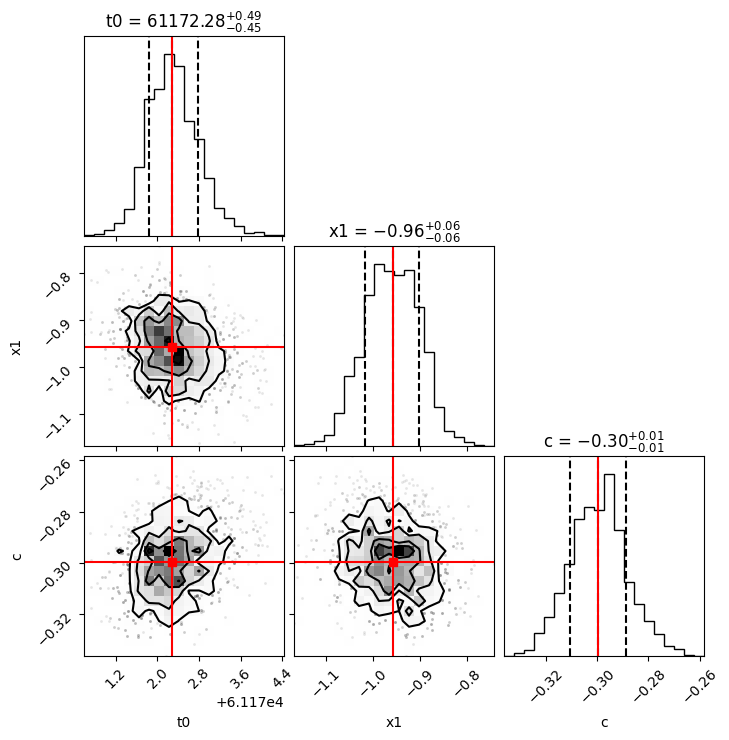

In [7]:
fig = corner.corner(
    samples,
    labels=params,
    truths=[t0_best, x1_best, c_best],
    truth_color='red',
    show_titles=True,
    title_fmt='.2f',
    quantiles=[0.16, 0.5, 0.84]
)
plt.show()

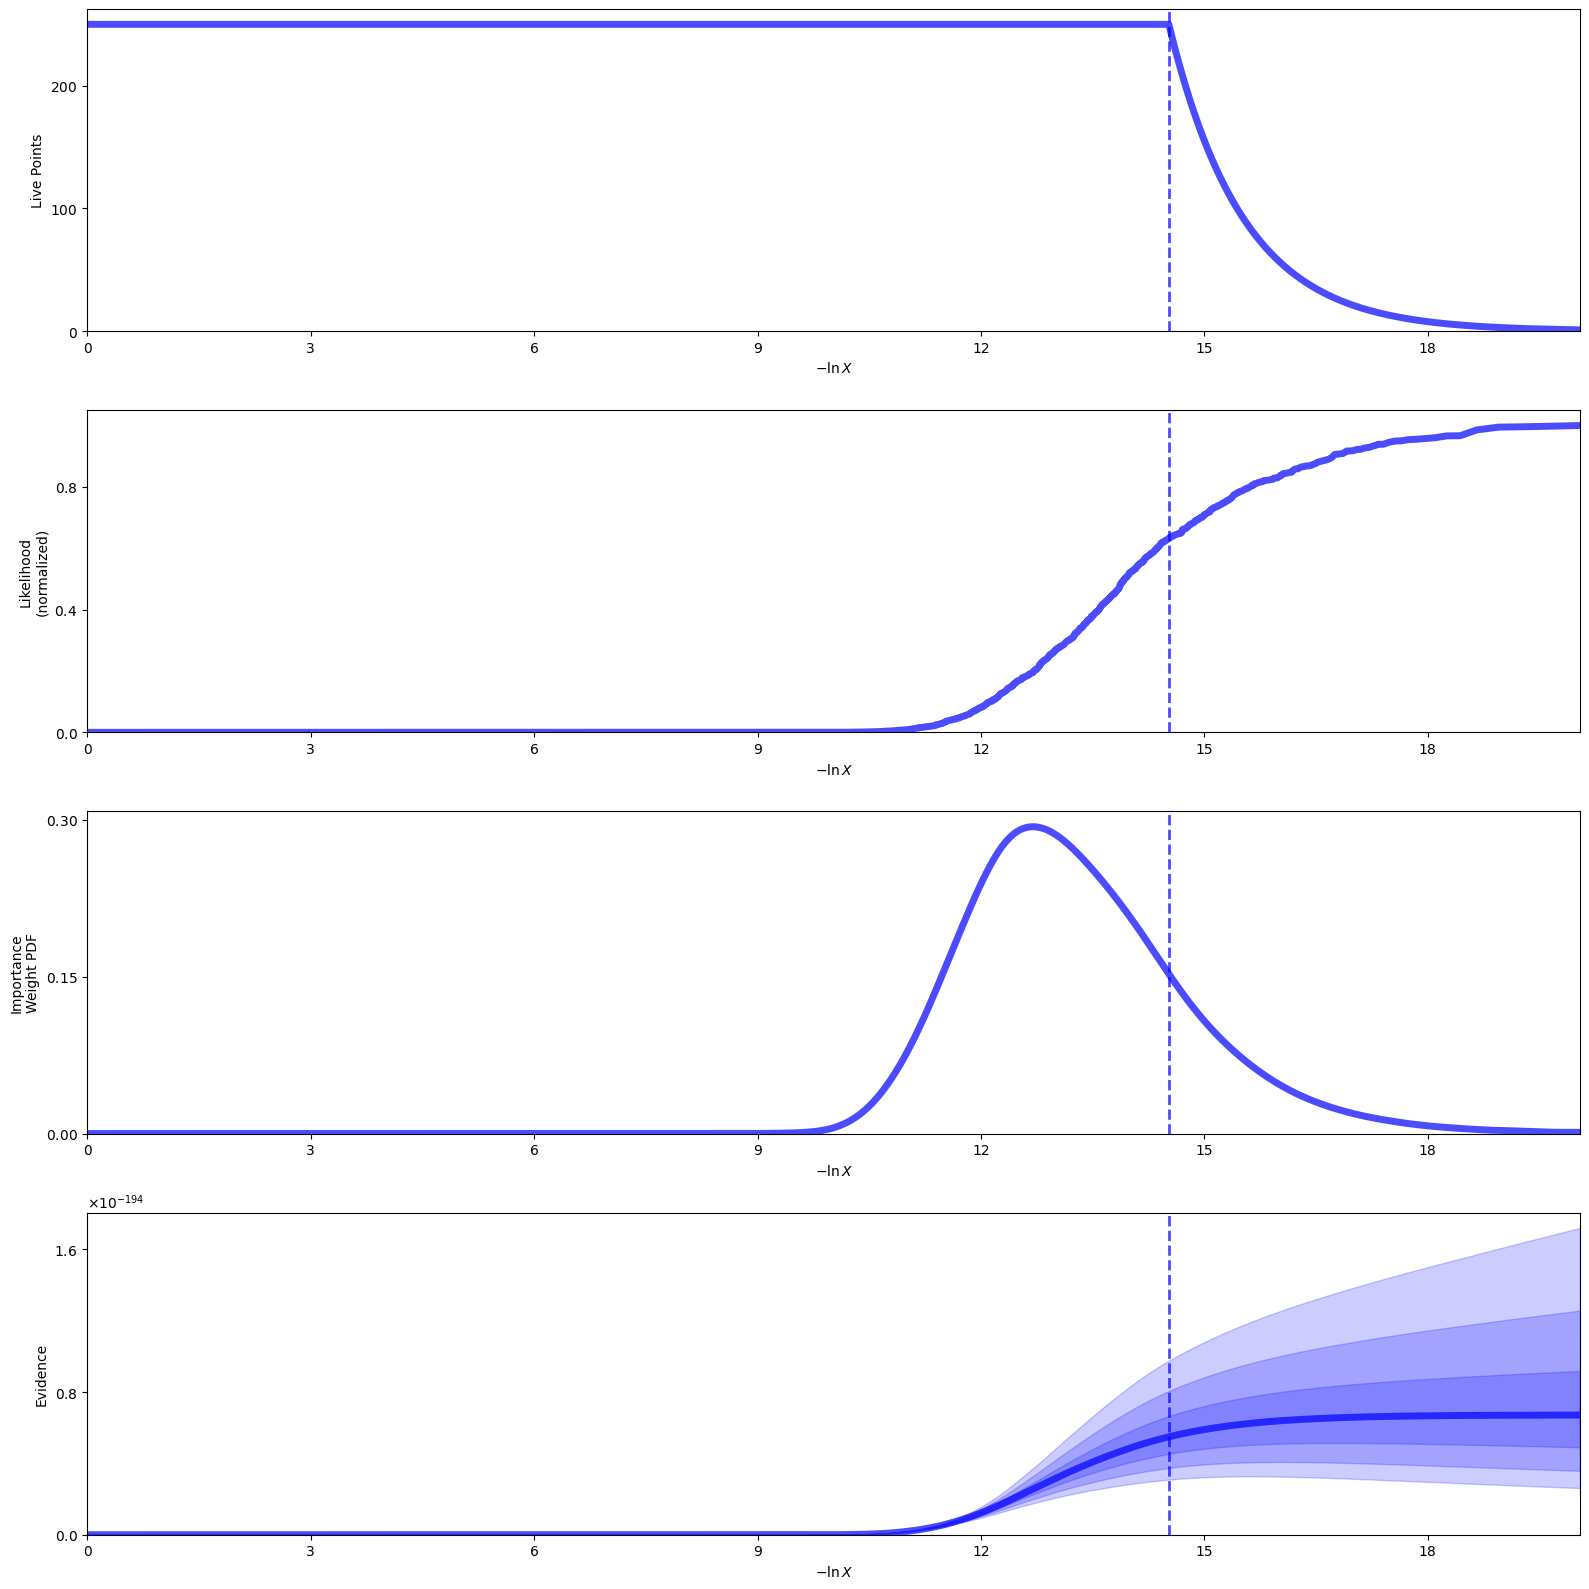

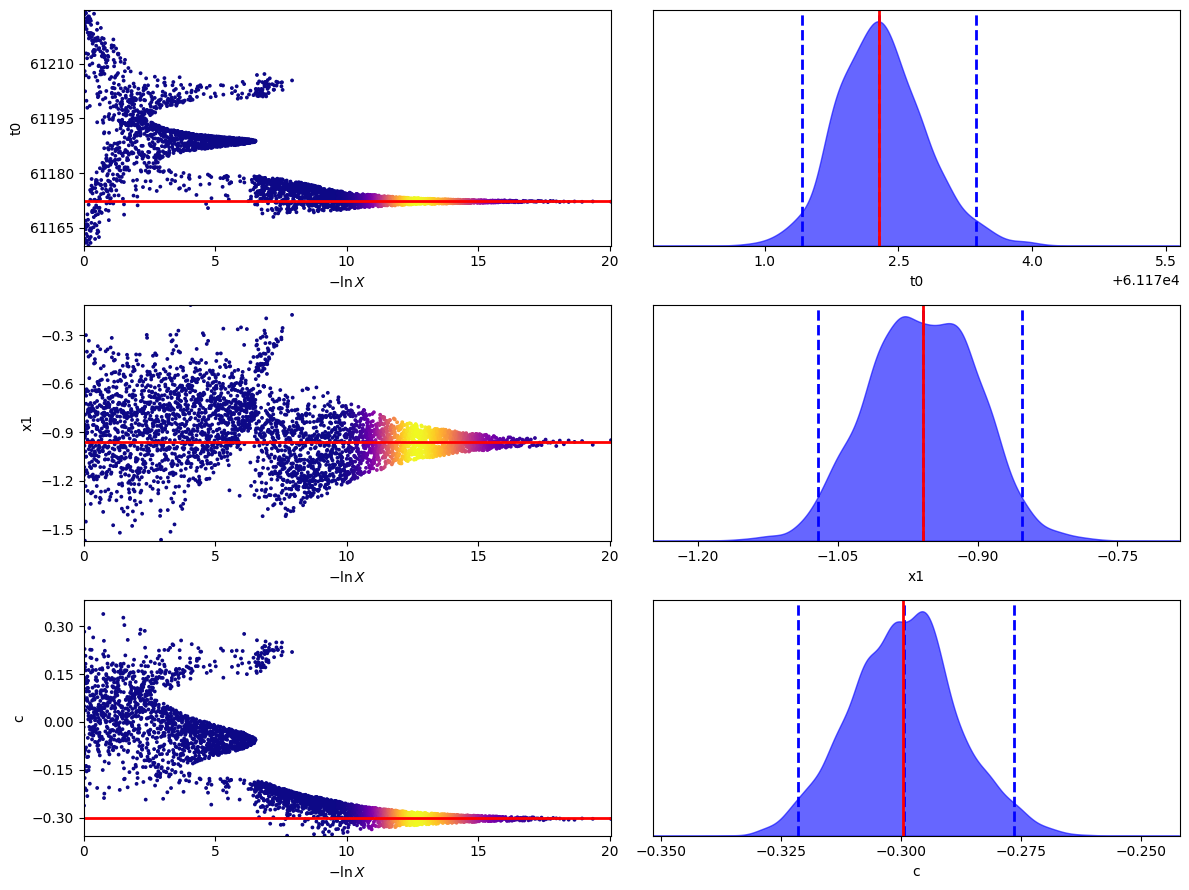

In [8]:
from dynesty import plotting as dyplot

# 1. Plot the summary of the nested sampling run (live points, bounds, logz, etc.)
fig, axes = dyplot.runplot(res)
plt.tight_layout()
plt.show()

# 2. Plot parameter traces
fig, axes = dyplot.traceplot(res, truths=[t0_best, x1_best, c_best], labels=params)
plt.tight_layout()
plt.show()